---
title: "The Earth System in a carbon cycle model"
subject: Project
venue: Integrierte Erdsysteme II
---
____
:::{important} Looking under the hood

This Notebook is a _wrapper_ for the carbon-cycle model published by [Joshua Krissansen-Totton et al. (2018)](https://doi.org/10.1073/pnas.1721296115). That means that it **sets up** the model, and makes some **basic plots** of the results.

But the actual **model code** is in the `.py` files in this directory, and your work will focus on:
1. **understanding**, and then
2. **modifying**
 this code in order to explore your group's scientific question.

Apart from some small syntax changes, the codebase is identical to that [made publicly available](https://github.com/joshuakt/early-earth-carbon-cycle) by the authors. So you will be looking under the hood of a scientific program straight out of recent influential research. 

:::

:::{warning} Model equations
The code comments sometimes refer to **numbered equations**. These can be found in the Supporting Information to the publication (at the bottom of [this page](https://www.pnas.org/doi/suppl/10.1073/pnas.1721296115/suppl_file/pnas.1721296115.sapp.pdf)) and are also reproduced in the slides on Moodle.
:::

#### __0. Import libraries and .PY codebase__

In [1]:
import numpy
import pylab # note from Greg -- this is an old name for matplotlib.pyplot! 
import scipy.stats
import time
global W,F_outgass,n,climp,tdep_weath,mod_sea,alt_frac,Mp_frac,CWF,carb_exp,sed_thick,F_carbw,fpel,deep_grad

from model_functions_reformate import Forward_Model #import forward model function
from n_out_functions_no_land import * #import functions used for sampling in Archean no land cases

#### __1.1. Set model options__

In [2]:
# Parallelize on/off number
# 0 - no parallelization (slow)
# number of threads (e.g. 4, 6, 8, 10, 12)
Parallelize = 7

# Tdep carbon chemistry constants
# 0 - carbon chemsitry assumes fixed temperature (faster, but slightly less accurate)
# 1 - carbon chemistry equilibrium constants are temperature dependent (slower, but more accurate)
Carbon_chem = 1 

# methane
# 0 - no atmospheric methane at all times
# 1 - 100 ppm methane in Proterozoic and 1% methane in Archean (see manuscript).
# turning this on also models a release of methane from 0.701 to 0.7
Methane_on = 0

## Save options. Will later be called by the forward model.
options_array = numpy.array([Parallelize, Carbon_chem, Methane_on])
numpy.save('options_array.npy',options_array)

#### __1.2. Set model parameter values__

In [3]:
## Generate random seed for sampling parameter distributions
#mtime = int(time.time()) % (1+100000) ### use remainder of this division as the random seed
mtime = 10 # change by Greg: keep the random seed constant to produce reproducible results
numpy.random.seed(mtime)

# Outgassing parameters
F_outgass=numpy.random.uniform(6e12,10e12) # Modern outgassing flux (mol C/yr)
mm=numpy.random.uniform(1.0,2.0) # Exponent determing relationhip between crustal production and outgassing (see equation S9)
n_out=numpy.random.uniform(0.0,0.73) # Exponent determing relationship between internal heat flow and outgassing (see equation S8)
#n_out=no_land_no_methane() # For no-land, no-methane case (see ReadMe)
#n_out=no_land_with_methane() # For no-land, with methane case (see ReadMe)

# Continental weathering parameters
tdep_weath=numpy.random.uniform(10.,40.0) # e-folding temperature for continental weathering (see equation 1)
climp=numpy.random.uniform(0.1,0.5) # exponent for CO2-dependence of continental silicate weathering (see equation 1)
carb_exp=numpy.random.uniform(0.1,0.5) # exponent of CO2-dependence continetnal carbonate weathering (see equation S2)
F_carbw=numpy.random.uniform(7e12,14e12) # Modern continental carbonate weathering (mol C/yr)

# Ocean and pore space parameters
W=numpy.random.uniform(2e4,1e6) # Mixing time (yrs) for pore space water.
Mp_frac=0.01  # Water fraction in pore space relative to ocean
deep_grad=numpy.random.uniform(0.8,1.4) # Gradient determining linear relationship between deep ocean temperatures and surface temperatures (see equation S20)

# Seafloor weathering parameters
mod_sea=.45e12  # Modern seafloor dissolution (mol/yr)
coef_for_diss=numpy.random.uniform(0.0,0.5) # Exponent determining pH-dependence of seafloor basalt dissolution and pore space pH (see equation S3)   
beta=numpy.random.uniform(0.0,2.0) # Exponent determining relationship between spreading rate and seafloor dissolution (see equation S10)
fpel=0.0 # Fraction pelagic carbonate - no longer in use this version of code
n=numpy.random.uniform(1.0,2.5) # Exponent for carbonate precipitation (see equation S19)
alt_frac=numpy.random.uniform(0.5,1.5) # Modern ratio of seafloor dissolution to carbonate precipitation (Table S2)
Ebas=numpy.random.uniform(60000.,100000.) # Effective activation energy for seafloor dissolution (see equation S3)

# Earth evolution parameters
lfrac=numpy.random.uniform(0.1,0.75)   # Archean land fraction (set negative for Archean ocean world e.g. lfrac=-0.2)
growth_timing=numpy.random.uniform(2.0,3.0) # Timing for growth of continents (Ga)
new_add_Ca=0.0 # Archean Ca abundance (range 0.0 to 500.0 for sensitvitiy tests Fig. S8 and S9)
sed_thick=numpy.random.uniform(0.2,1.0) # sediment thickness in Archean relative to modern (see equation S5) 
CWF=numpy.random.uniform(0.1,0.999) # Biological enhancement of weathering (Archean value relative to modern)

#### __1.3. Run model__

In [4]:
## Define a function that runs the model and checks the output
def try_run_forward():
    ## Run forward model once with arbitrary parameters to define size of array that will contain outputs
    [temporary_array,imb]=Forward_Model(6.0e4,6e12,1.7,0.3,13.7,0.5e12,0.7,0.01,0.9,0.3,1.0,11e12,0.0,0.5,1.0,0.2,0.3,0.5,0.5,2.5,0.01,90000)
    all_output=numpy.zeros([len(temporary_array),len(temporary_array[4]),1]) # This array will contain forward model outputs

    try:
        [all_output[:,:,0],imb]=Forward_Model(W,F_outgass,n,climp,tdep_weath,mod_sea,alt_frac,Mp_frac,lfrac,carb_exp,sed_thick,F_carbw,fpel,CWF,deep_grad,coef_for_diss,beta,n_out,mm,growth_timing,new_add_Ca,Ebas)
        #Dissolution_change_array[ii]=all_output[19,numpy.size(all_output[19,:,:])/it_num-1,ii]/all_output[19,0,ii]
        if (numpy.isnan(all_output[7,98,0]))or(all_output[14,98,0]<0.0): # If non-sensical outputs, report error and try iteration again
            print("error, forward model produced non physical outputs - try again")
            print(" ")
        else:
            if abs(imb)>0.2: #Check mass conservation, print warning and retry if large imbalance
                print("error, model not conserving mass - try again")
            else:
                return all_output,imb,n_out,beta,mm,coef_for_diss,Ebas,deep_grad,carb_exp,tdep_weath,climp,W,n #Return iteration number, carbon cycle outputs, mass imbalance, and various input parameters
    except: # if forward model call unsuccessful, print error message and try again
        print("error, forward model failed - try again")
        print(" ")

## Call the function above and get the results
[all_output,imbalan,n_out,beta,mm,coef_for_diss,Ebas,deep_grad,carb_exp,tdep_weath,climp,W,n]=try_run_forward()

# Create arrays for output variables of interest:
all_output[4,:,0]=all_output[4,:,0]/1e9 # Convert time axis from years to Ga

confidence_pH_o=all_output[5,:,:] # ocean pH
confidence_CO2o=all_output[6,:,:] # atmospheric pCO2

confidence_Tsurf=all_output[17,:,:] # Average surface temperature

confidence_Fd=all_output[19,:,:] # Seafloor dissolution flux
confidence_Fs=all_output[20,:,:] # Continental silicate weathering flux

confidence_Volc=all_output[24,:,:] # Volcanic outgassing flux

Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering scale: 1.0
Weathering

#### __2. Visualise results__

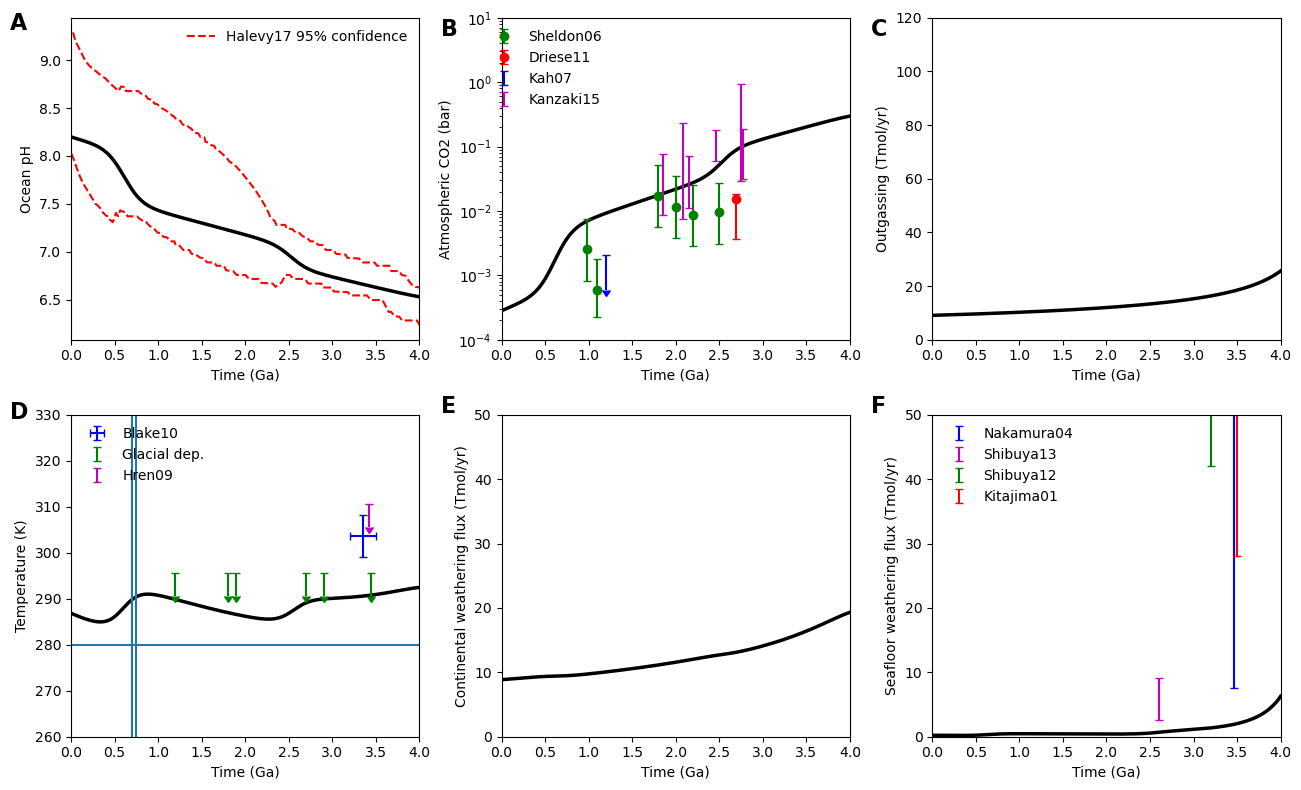

In [ ]:
#################################
### Plotting figure #############
#################################

ppCO2=10**-6 ## For converting ppm to partial pressures in bar

strt_lim=0.0 # lower limit on x-axis (0 Ga)
fin_lim=4.0 # upper limit on x-axis (4 Ga)

pylab.figure(figsize=(13,8)) ## create multipanel figure for pH, CO2, outgassing, temp, continental and silicate weathering through time  

# Subplot for ocean pH through time
pylab.subplot(2, 3, 1) 
pylab.plot(all_output[4,:,0],confidence_pH_o,'k',linewidth=2.5) # plot median ocean pH 
#pylab.fill_between(all_output[4,:,0], confidence_pH_o[0], confidence_pH_o[2], color='grey', alpha=0.4) #plot ocean pH confidence interval
pylab.xlabel('Time (Ga)')
pylab.ylabel('Ocean pH')
pylab.xlim([strt_lim,fin_lim]) # x axis limits
HB_low=numpy.loadtxt('Halevy_Bachan_low.txt',delimiter=',') # load Halevy and Bachan 95% confidence lower bound
HB_high=numpy.loadtxt('Halevy_Bachan_high.txt',delimiter=',') # load Halevy and Bachan 95% confidence upper bound
pylab.plot(HB_low[:,0],HB_low[:,1],'r--',label='Halevy17 95% confidence') # plot Halevy and Bachan for comparison
pylab.plot(HB_high[:,0],HB_high[:,1],'r--')# plot Halevy and Bachan for comparison
pylab.legend(numpoints=1,frameon=False) #display legend
pylab.text(-0.7, 9.5, 'A', fontsize=16, fontweight='bold', va='top') # label subplot

#subplot for atmospheric CO2 through time
pylab.subplot(2, 3, 2) 
pylab.semilogy(all_output[4,:,0],confidence_CO2o,'k',linewidth=2.5)
#pylab.fill_between(all_output[4,:,0], confidence_CO2o[0], confidence_CO2o[2], color='grey', alpha=0.4)
### Literature proxies for comparison
Sheldon_CO2_low=numpy.array([8.2,7.67,10.1,15.,0.6,2.2])*370*ppCO2 # lower limit Sheldon 2006
Sheldon_CO2_best=numpy.array([26.,23,31,45.9,1.6,7.0])*370*ppCO2 # median estimate Sheldon 2006
Sheldon_CO2_hi=numpy.array([72.7,69,93,138,4.9,20.3])*370*ppCO2 # upper limit Sheldon 2006
Sheldon_dates=numpy.array([2.5,2.2,2.0,1.8,1.1,0.98]) # time in Ga
pylab.errorbar(Sheldon_dates,Sheldon_CO2_best,yerr=[Sheldon_CO2_best-Sheldon_CO2_low,Sheldon_CO2_hi-Sheldon_CO2_best],color='g',marker='o',linestyle="None",label='Sheldon06',capsize=3) #plot errorbar
Driese_CO2_low=numpy.array([10])*370*ppCO2 # lower limit Driese 2011
Driese_CO2_best=numpy.array([41])*370*ppCO2 # median estimate Driese 2011
Driese_CO2_hi=numpy.array([50])*370*ppCO2 # upper limit Driese 2011
Driese_dates=numpy.array([2.69]) # time in Ga 
pylab.errorbar(Driese_dates,Driese_CO2_best,yerr=[Driese_CO2_best-Driese_CO2_low,Driese_CO2_hi-Driese_CO2_best],color='r',marker='o',linestyle="None",label='Driese11',capsize=3) #plot errorbar
KahRiding_CO2=numpy.array([10])*360*ppCO2 # Kah and Riding 07 upper limit
KahRiding_dates=numpy.array([1.2]) # time in Ga
pylab.errorbar(KahRiding_dates, KahRiding_CO2-1500*ppCO2, yerr=1500*ppCO2, uplims=True,linestyle='none',color='b',label='Kah07',capsize=3) #plot errorbar
KanzakiMurakami_CO2_low=numpy.array([85,78,160,30,20,23])*370*ppCO2 # Kanzaki and Murakami 2015 lower limit
KanzakiMurakami_CO2_hi=numpy.array([510,2500,490,190,620,210])*370*ppCO2 # Kanzaki and Murakami 2015 median
KanzakiMurakami_CO2_best= 0.5*(KanzakiMurakami_CO2_low+ KanzakiMurakami_CO2_hi) # Kanzaki and Murakami 15 upper limit
KanzakiMurakami_dates=numpy.array([2.77,2.75,2.46,2.15,2.08,1.85]) #time in Ga
pylab.errorbar(KanzakiMurakami_dates,KanzakiMurakami_CO2_best,yerr=[KanzakiMurakami_CO2_best-KanzakiMurakami_CO2_low,KanzakiMurakami_CO2_hi-KanzakiMurakami_CO2_best],color='m',linestyle="None",label='Kanzaki15',capsize=3) #plot errorbar
### End of literature proxy comparison
pylab.xlabel('Time (Ga)')
pylab.ylabel('Atmospheric CO2 (bar)')
pylab.legend(loc=2,numpoints=1,frameon=False,bbox_to_anchor=(-.07, 1.0, 1.0, 0)) # plot legend
pylab.xlim([strt_lim,fin_lim]) # x axis limit
pylab.ylim([1e-4,10.0]) # limit y-axis from 1e-4 to 10 bar
pylab.text(-0.7, 10., 'B', fontsize=16, fontweight='bold', va='top') # label subplot

pylab.subplot(2,3,3)
pylab.plot(all_output[4,:,0],confidence_Volc/1e12,'k',label='Total',linewidth=2.5) # plot median outgassing flux
#pylab.fill_between(all_output[4,:,0], confidence_Volc[0]/1e12, confidence_Volc[2]/1e12, color='grey', alpha=0.4) #outgassing flux confidence interval
pylab.ylabel('Outgassing (Tmol/yr)')
pylab.xlabel('Time (Ga)')
pylab.xlim([strt_lim,fin_lim]) # x axis limits
pylab.ylim([0,120.0]) # y axis limits
pylab.text(-0.7, 120, 'C', fontsize=16, fontweight='bold', va='top') # label subplot

# Subplot for surface temperature
pylab.subplot(2, 3, 4) 
pylab.plot(all_output[4,:,0],confidence_Tsurf,'k',linewidth=2.5) # plot median surface temperature
#pylab.fill_between(all_output[4,:,0], confidence_Tsurf[0], confidence_Tsurf[2], color='grey', alpha=0.4) # plot confidence interval surface temperature
pylab.ylabel('Temperature (K)')
pylab.xlabel('Time (Ga)')
Blake_dates=numpy.array([3.35]) # time in Ga for Blake 2010 temperature constraint
Blake_temp_low=numpy.array([26])+273.15 # lower estimate Blake 2010
Blake_temp_high=numpy.array([35])+273.15 # upper estimate Blake 2010
Blake_best=0.5*(Blake_temp_low+Blake_temp_high) # midpoint Blake 2010
pylab.errorbar(Blake_dates,Blake_best,xerr=0.15,yerr=Blake_temp_high-Blake_best,color='b',linestyle="None",label='Blake10',capsize=3) # plot Blake 2010 temperature proxy
Temp_dates=numpy.array([2.9,2.7,1.8,1.9,1.2,3.45]) # Ages for glacial constraints (see Appendix D).
Up_limit=numpy.array([25.,25.,25.,25.,25.,25.])+273.15 # Define maximum global mean temperature during glacial events to be 25 K
pylab.errorbar(Temp_dates, Up_limit-2.5, yerr=5, uplims=True,linestyle='none',color='g',label='Glacial dep.',capsize=3) # plot glacial temperature constraints
pylab.errorbar([3.42], 273.15+40-2.5, yerr=5, uplims=True,linestyle='none',color='m',label='Hren09',capsize=3) # plot Hren 2009 temperature proxy
pylab.legend(loc=2,numpoints=1,frameon=False) #display legend
pylab.xlim([strt_lim,fin_lim]) # x axis limits
pylab.ylim([260,330]) # y axis limits
pylab.text(-0.7, 333, 'D', fontsize=16, fontweight='bold', va='top') # label subplot
pylab.axhline(280, xmin=0, xmax=4)
pylab.axvline(0.75)
pylab.axvline(0.7)


#subplot for continental weathering flux through time
pylab.subplot(2, 3, 5)
pylab.plot(all_output[4,:,0],confidence_Fs/1e12,'k',label='Cont. weathering',linewidth=2.5) # plot median continental weathering
#ylab.fill_between(all_output[4,:,0], confidence_Fs[0]/1e12, confidence_Fs[2]/1e12, color='grey', alpha=0.4) # plot confidence interval
pylab.ylabel('Continental weathering flux (Tmol/yr)')
pylab.xlabel('Time (Ga)')  
pylab.ylim([0,50]) # y axis limits
pylab.xlim([strt_lim,fin_lim]) # x axis limits
pylab.text(-0.7, 53, 'E', fontsize=16, fontweight='bold', va='top') # label subplot

#subplot for seafloor weathering flux through time
pylab.subplot(2, 3, 6)
pylab.plot(all_output[4,:,0],confidence_Fd/1e12,'k',linewidth=2.5) # plot median seafloor dissolution
#pylab.fill_between(all_output[4,:,0], confidence_Fd[0]/1e12, confidence_Fd[2]/1e12, color='grey', alpha=0.4) # plot seafloor dissolution confidence intervals
Nakamura_Kato_date=numpy.array([3.46]) # Age of Nakamura and Kato seafloor carbonate mesaurements (Ga)
Nakamura_Kato_low=numpy.array([7.6e12])/1e12 # See Appendix D for lower bound calculation
Nakamura_Kato_high=numpy.array([6.5e13])/1e12 # See Appendix D for upper bound calculation
NK_best=0.5*(Nakamura_Kato_low+Nakamura_Kato_high) # Find mid point of range
pylab.errorbar(Nakamura_Kato_date,NK_best,yerr=[NK_best-Nakamura_Kato_low,Nakamura_Kato_high-NK_best],color='b',linestyle="None",label='Nakamura04',capsize=3) # plot errorbar
Shibuya2013=numpy.array([2.6]) # Age of Shibuya 2013 seafloor carbonate mesaurements (Ga)
Shibuya2013_hi=numpy.array([9.1e12])/1e12 # See Appendix D
Shibuya2013_lo=numpy.array([2.6e12])/1e12 # See Appendix D
Shib2013_best=0.5*(Shibuya2013_lo+Shibuya2013_hi) # find mid point
pylab.errorbar(Shibuya2013,Shib2013_best,yerr=[Shib2013_best- Shibuya2013_lo,Shibuya2013_hi-Shib2013_best],color='m',linestyle="None",label='Shibuya13',capsize=3) # plot errorbar
Shibuya2012=numpy.array([3.2]) # Age of Shibuya 2012 seafloor carbonate mesaurements (Ga)
Shibuya2012_hi=numpy.array([2.6e14])/1e12 # See Appendix D
Shibuya2012_lo=numpy.array([42e12])/1e12 # See Appendix D
Shib2012_best=0.5*(Shibuya2012_lo+Shibuya2012_hi) # find mid point
pylab.errorbar(Shibuya2012,Shib2012_best,yerr=[Shib2012_best- Shibuya2012_lo,Shibuya2012_hi-Shib2012_best],color='g',linestyle="None",label='Shibuya12',capsize=3)# plot errorbar
NrthPole=numpy.array([3.5]) # Age of Kitajima seafloor carbonate measurements (Ga)
NrthPole_hi=numpy.array([250e12])/1e12 # See Appendix D
NrthPole_lo=numpy.array([2.8e13])/1e12 # See Appendix D
NrthPole_best=0.5*(NrthPole_lo+NrthPole_hi) # find mid point
pylab.errorbar(NrthPole,NrthPole_best,yerr=[NrthPole_best- NrthPole_lo,NrthPole_hi-NrthPole_best],color='r',linestyle="None",label='Kitajima01',capsize=3) # plot errorbar
pylab.text(-0.7, 53, 'F', fontsize=16, fontweight='bold', va='top') # label subplot
pylab.legend(loc=2)     
pylab.xlim([strt_lim,fin_lim])
pylab.ylim([0,50])
pylab.ylabel('Seafloor weathering flux (Tmol/yr)')
pylab.xlabel('Time (Ga)')  
pylab.legend(loc=2,numpoints=1,frameon=False)  
pylab.tight_layout()
# pylab.savefig('baseline.png')
##################################################   

*Documentation*
Adjusted Parameters:
Silicate weathering
Silicate weathering was adjusted to increase during the separation of the supercontinent from 0.75 to 0.7 Ga. This was done using exponential in and decreases for a spike factor within the time interval. Outside of this time interval the spike factor equals zero, within one. This is then scaled using an additional factor to in- and decrease the silicate weathering rate. The result is that within the separation we model an increase in silicate weathering flux, leading to a decrease in temperature and atmospheric CO2.
To model these in and decrease the functions need to be smoothed as the differential equations do not handle jumping values very well.


Methane release
If Methane option in the parameters is turned on, the model will calculate a release of methane from 0.7 to 0.701 Ga. This was done by adjusting which climate model is used to calculate the temperature. During the Archaic a model with higher Methane concentrations is used than during the Proterozoic. To model the release, the Archaic temperature calculation was used over the release timeframe. To specify which temperature model should be used during which time smoothing functions were used to calculate the in- and decrease- at the interval edges. This gives us the factors w0, w1 and w2 which either equal 1 or 0, depending on which time interval the time step falls into. Multiplying these with the correct temperature calculations and adding all together lets us calculate the surface temperature displayed in the diagram.
Modeling only the methane release the model responds with a decrease in atmospheric CO2 and an increase in temperature which matches the models understanding of methane as primarily a greenhouse gas. [WAS FÜR ÜÜS FEHLT ISCH DAS DE LANGZIIT EFFEKT KÜHLEND SII SETTI.ES DRUCKT S CO2 STÄRKER ABE ALS DASES D TEMP ERHÖHT; ÄNDERET S PROBLEM VOM SNOWBALL EARTH MIT MER KRIEGT S CO2 NED USEM SYSTEM BITZ AB. VERGLICHE MIT EM SILIKAT WEATHERING HETT DE KURZI METHAN RELEASE ALLERDINGS NUR EN EHER CHLIINE IISFLUSS UFS GANZE. JE LÄNGER D'FREISETZIG DEST KRASSER WIRD DE EFFEKT.]

Albedo
ENDGEGNER
-> hysterese kurve: ab 280K sollte es einen sprung runter geben, dann langsam ansteigen und ab ca 260 wieder einen sprung nach oben. ABER -> wir können max einen sprung implementieren, der zeite geht nicht
-> Albedo effekt welcher in kurve angegeben ist läuft nicht, mit sachen grösser als 0.05 albedo stirbt das programm
-> die albedo wird relativ zu heute angepasst: heute=0.3, increase um faktor xxx währen runaway snowball earth.
-> Beim modellieren der abnhame der temperatur verstärkt mit dem albedo effekt multiplizieren sich zwei exponentielle abnahmen. für differentialgelichungslöser zu steil-> wird aufgenommen als sprung.